In [1]:
import os
import numpy as np
import pandas as pd
import scipy
import time
import sklearn

import anndata as ad
import scanpy as sc
import tensorflow as tf

In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
from scMTG import scMTG, util

# 1. Data preparation

### 1.1 Load the demo dataset (sub-dataset of [GSE132188](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE132188)).

In [5]:
data_path = './data'
adata = sc.read('%s/%s.h5ad' % (data_path, 'pancreas_demo'))
print(adata)

AnnData object with n_obs × n_vars = 4000 × 3000
    obs: 'time', 'cell_type'


In [6]:
time_field, cell_field = 'time', 'cell_type'
times0 = list(adata.obs[time_field].unique())
print(times0)

[12.5, 13.5, 14.5, 15.5]


In [7]:
adata.obs[time_field].value_counts()

time
12.5    1000
13.5    1000
14.5    1000
15.5    1000
Name: count, dtype: int64

In [8]:
adata.obs[cell_field].value_counts()

cell_type
Mat. Acinar     658
Ductal          492
Tip             445
Prlf. Acinar    370
Ngn3 low EP     339
Endocrine       303
Ngn3 high EP    301
Prlf. Ductal    281
Prlf. Tip       270
Fev+            225
Prlf. Trunk     126
Multipotent     125
Trunk            65
Name: count, dtype: int64

### 1.2 Compute the growth rate.

In [9]:
def score_genes(adata, gene_set_proliferation, gene_set_apoptosis, 
                proliferation_key="proliferation", apoptosis_key="apoptosis"):
    with open(f"data/{gene_set_proliferation}_proliferation.txt") as fin:
        gene_set_proliferation = sorted(tf.strip() for tf in fin.readlines())
    if gene_set_proliferation is not None:
        sc.tl.score_genes(adata, gene_set_proliferation, score_name=proliferation_key)

    with open(f"data/{gene_set_apoptosis}_apoptosis.txt") as fin:
        gene_set_apoptosis = sorted(tf.strip() for tf in fin.readlines())
    if gene_set_apoptosis is not None:
        sc.tl.score_genes(adata, gene_set_apoptosis, score_name=apoptosis_key)

In [10]:
score_genes(adata, gene_set_proliferation='mouse', gene_set_apoptosis='mouse')

In [11]:
proliferation_key = "proliferation"
apoptosis_key = "apoptosis"
growth_rates = []
for i in range(len(times0[:-1])):
    delta_t = times0[i+1]-times0[i]
    growth_rates.append(util.growth_rate(adata[adata.obs[time_field]==times0[i]], delta_t=delta_t))
last_size = len(adata[adata.obs[time_field]==times0[-1]])
growth_rates.append(np.ones(last_size, dtype='float32') / last_size)

# 2. run scMTG

### 2.1 Train scMTG model.

In [12]:
# Do not perform interpolation.
datas = [adata.X[adata.obs[time_field]==item].todense() for item in times0]
for i in range(len(times0)):
    print(i, datas[i].shape, growth_rates[i].shape)

0 (1000, 3000) (1000,)
1 (1000, 3000) (1000,)
2 (1000, 3000) (1000,)
3 (1000, 3000) (1000,)


In [13]:
# Perform interpolation.
interpolate_times = 2
delta_t = float(times0[interpolate_times+1]) - float(times0[interpolate_times-1])
growth_rates[interpolate_times-1] = util.growth_rate(adata[adata.obs[time_field]==times0[interpolate_times-1]], delta_t=delta_t)
for i in range(len(datas)):
    print(i, datas[i].shape, growth_rates[i].shape)
datas.pop(interpolate_times)
growth_rates.pop(interpolate_times)
print(len(datas), len(growth_rates))

0 (1000, 3000) (1000,)
1 (1000, 3000) (1000,)
2 (1000, 3000) (1000,)
3 (1000, 3000) (1000,)
3 3


In [14]:
data_name = 'pancreas'
params = {'dataset': data_name,
 'output_dir': './output',
 'alpha': 10,
 'beta': 5,
 'sd': 0.5,
 'e_dim': adata.shape[1],
 'z_dim': 30,
 'noise_dim': 8,
 'lr': 0.0002,
 'g_d_freq': 3,
 'ae_gan_freq': 5,
 'nb_time': len(datas),
 'e_units': [2048, 1024, 512, 256],
 'd_units': [256, 512, 1024, 2048],
 'gen_units': [64, 128, 128, 64],
 'dis_units': [64, 128, 64],
 'save_model': True,
 'save_res': True}

In [15]:
model = scMTG(params)

2026-06-17 15:22:55.820296: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-06-17 15:22:55.821060: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: n11.openness.cas
2026-06-17 15:22:55.821155: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: n11.openness.cas
2026-06-17 15:22:55.821603: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 595.58.3
2026-06-17 15:22:55.821878: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: Not found: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  595.58.03  Release Build  (dvs-builder@U22-I3-AM25-28-3)  Tue Mar 17 19:55:10 UTC 2026
GCC version:  gcc version 15.2.0 (Ubuntu 15.2.0-16ubuntu1) 
"
2026-06-17 15:22:55.826570: I tensorflo

Model: "base_fully_connected_net"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 2048)              6146048   
_________________________________________________________________
batch_normalization (BatchNo multiple                  0 (unused)
_________________________________________________________________
dropout (Dropout)            (None, 2048)              0         
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 2048)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 1024)              2098176   
_________________________________________________________________
batch_normalization_1 (Batch multiple                  0 (unused)
_________________________________________________________________
dropout_1 (Dropout)          (None, 1024) 

In [16]:
model.train(data=datas, weights=growth_rates, batch_size=16, n_iter=100000, batches_per_verbose=500)

2026-06-17 15:23:09.521641: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Iteration [0] : loss_t [9.5984], loss_rec [0.8065], loss_gp [0.3075], loss_d [0.0962], loss_g [-0.0771] loss_td [1.1395]
Iteration [500] : loss_t [2.9141], loss_rec [0.4253], loss_gp [0.0320], loss_d [-1.5331], loss_g [0.1910] loss_td [0.7021]
Iteration [1000] : loss_t [4.3073], loss_rec [0.4298], loss_gp [0.0191], loss_d [-1.5969], loss_g [-0.1692] loss_td [1.0905]
Iteration [1500] : loss_t [4.2224], loss_rec [0.4248], loss_gp [0.0043], loss_d [-1.3242], loss_g [-0.1329] loss_td [1.0424]
Iteration [2000] : loss_t [5.1624], loss_rec [0.4160], loss_gp [0.0115], loss_d [-2.4465], loss_g [-0.1315] loss_td [1.4420]
Iteration [2500] : loss_t [56.9905], loss_rec [0.3975], loss_gp [0.0068], loss_d [-1.8066], loss_g [-0.5231] loss_td [11.7709]
Iteration [3000] : loss_t [19.0746], loss_rec [0.3916], loss_gp [0.0365], loss_d [-2.3043], loss_g [-0.4217] loss_td [4.2088]
Iteration [3500] : loss_t [34.5041], loss_rec [0.3977], loss_gp [0.0124], loss_d [-2.4392], loss_g [-0.4705] loss_td [7.3785]
It

Iteration [33000] : loss_t [2.2616], loss_rec [0.3511], loss_gp [0.0047], loss_d [-1.1249], loss_g [-0.9419] loss_td [0.7861]
Iteration [33500] : loss_t [2.0023], loss_rec [0.3691], loss_gp [0.0037], loss_d [-1.2598], loss_g [-0.8516] loss_td [0.7416]
Iteration [34000] : loss_t [1.1429], loss_rec [0.3506], loss_gp [0.0070], loss_d [-1.1690], loss_g [-0.7904] loss_td [0.5363]
Iteration [34500] : loss_t [1.3950], loss_rec [0.3508], loss_gp [0.0021], loss_d [-0.8785], loss_g [-0.8715] loss_td [0.5546]
Iteration [35000] : loss_t [1.0915], loss_rec [0.3618], loss_gp [0.0037], loss_d [-1.0057], loss_g [-0.8529] loss_td [0.5102]
Iteration [35500] : loss_t [1.2215], loss_rec [0.3541], loss_gp [0.0059], loss_d [-1.2288], loss_g [-0.8290] loss_td [0.5733]
Iteration [36000] : loss_t [0.7441], loss_rec [0.3514], loss_gp [0.0048], loss_d [-1.2585], loss_g [-0.8388] loss_td [0.4883]
Iteration [36500] : loss_t [0.9156], loss_rec [0.3681], loss_gp [0.0054], loss_d [-0.9281], loss_g [-0.8401] loss_td [

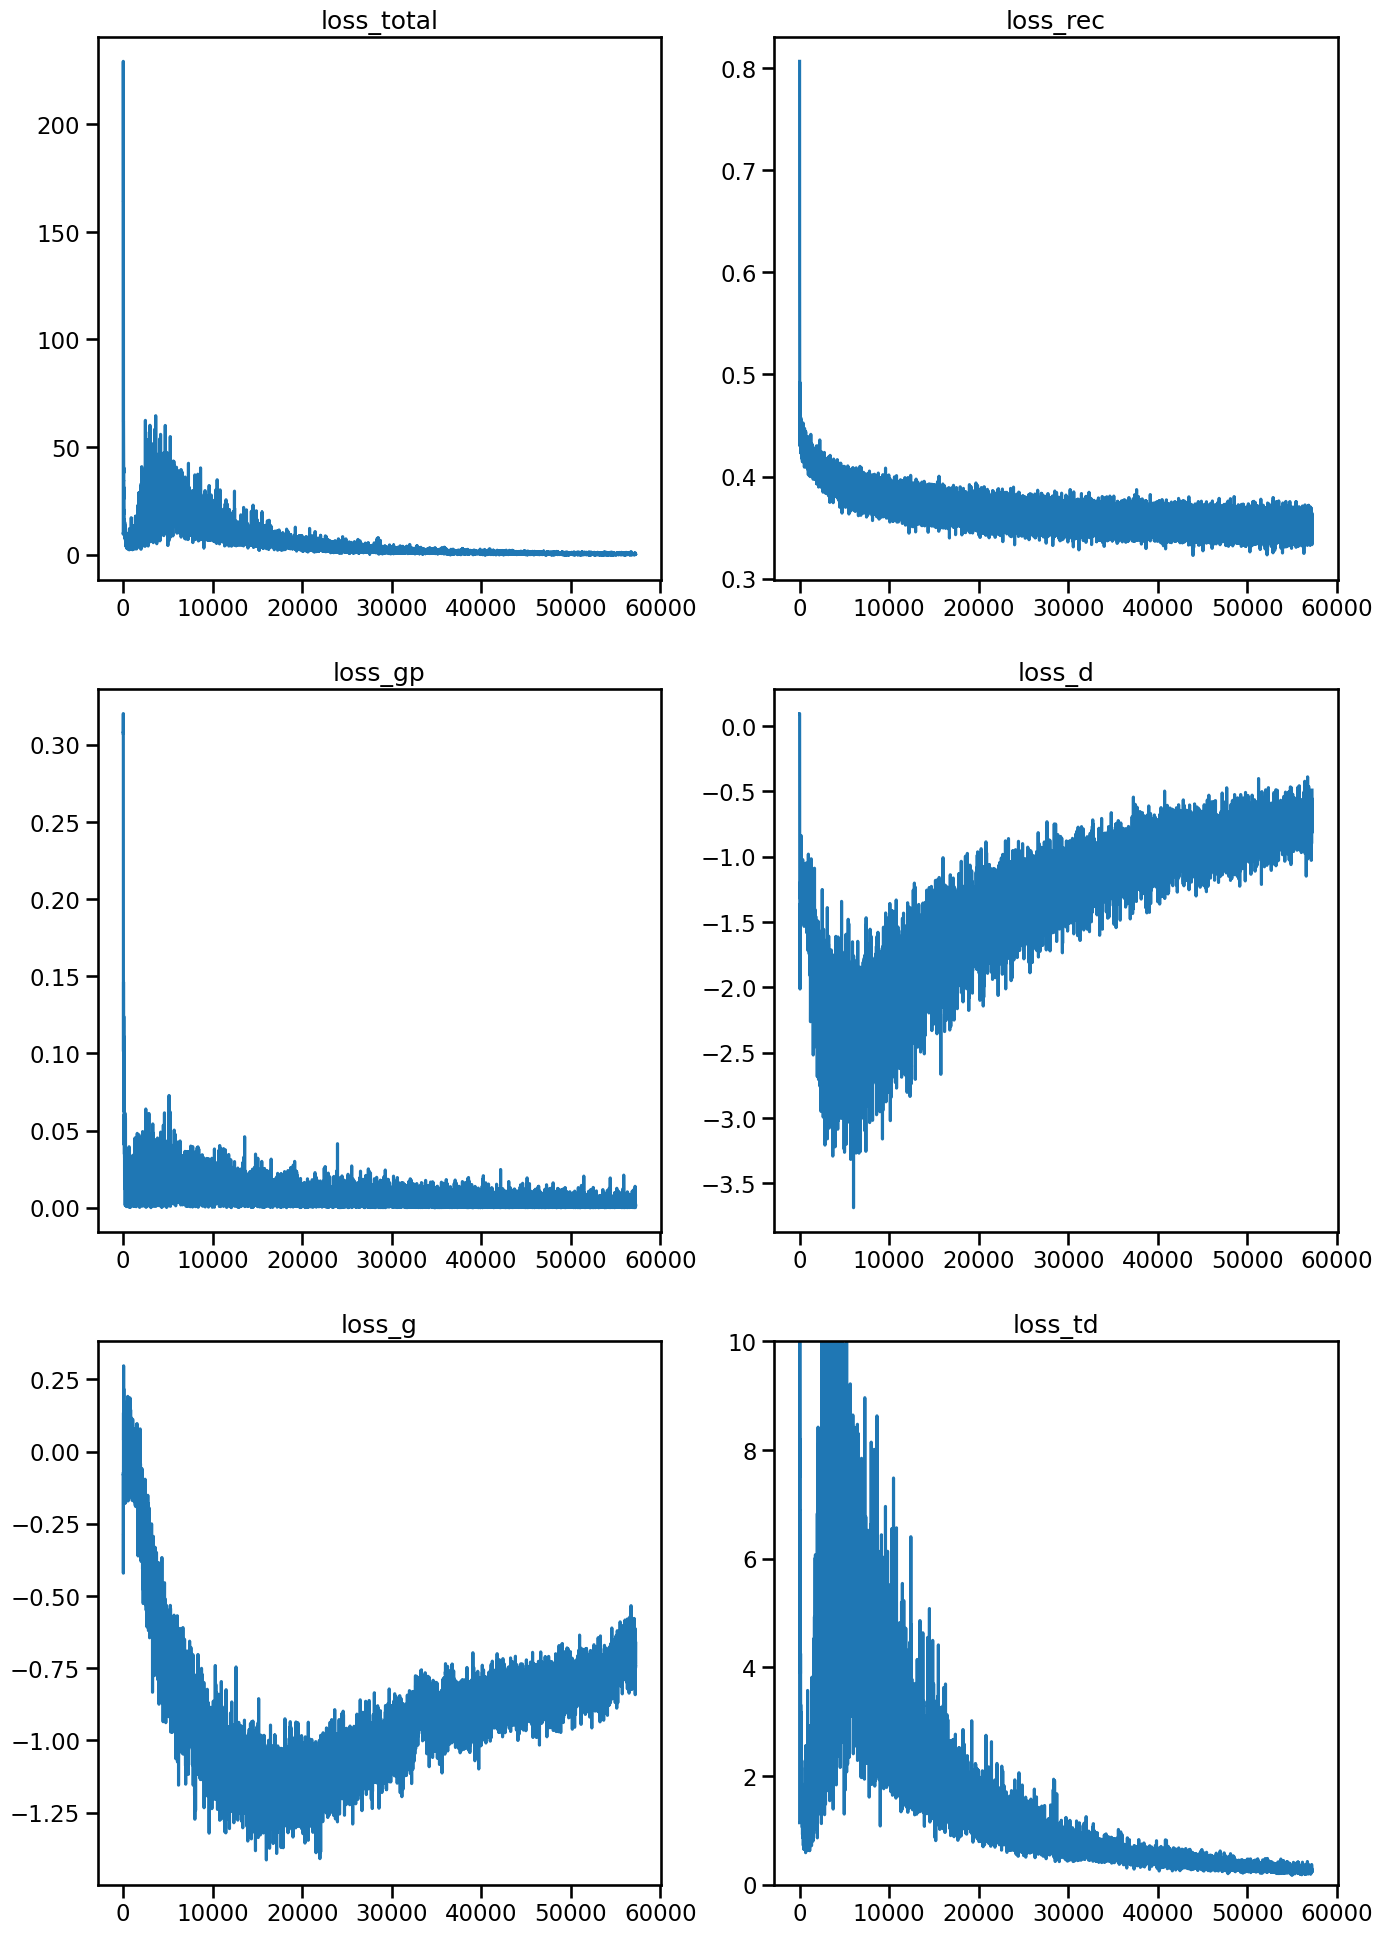

In [17]:
loss_pd = pd.read_csv('./output/%s/loss_pd.csv' % (model.timestamp), sep='\t')
f = plt.figure(figsize=(16, 24))
ax = f.add_subplot(3, 2, 1)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_total'])
ax.set_title('loss_total')

ax = f.add_subplot(3, 2, 2)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_rec'])
ax.set_title('loss_rec')

ax = f.add_subplot(3, 2, 3)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_gp'])
ax.set_title('loss_gp')

ax = f.add_subplot(3, 2, 4)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_d'])
ax.set_title('loss_d')

ax = f.add_subplot(3, 2, 5)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_g'])
ax.set_title('loss_g')

ax = f.add_subplot(3, 2, 6)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_td'])
plt.ylim(0,10.0)
ax.set_title('loss_td')
plt.show()

### 2.2 Generate transition matrix.

In [20]:
times = 0
trans_mtx = model.compute_trans_mat(times=times)
print(trans_mtx.shape)

(1000, 1000)


In [21]:
# Generate cell-type-specifc transition matrix.
source, target = times0[times], times0[times+1]
print(source, target)

source_labels = adata[adata.obs[time_field]==source].obs[cell_field]
target_labels = adata[adata.obs[time_field]==target].obs[cell_field]
ps = []
for ct1 in list(source_labels.cat.categories):
    p1s = []
    p1 = np.sum(trans_mtx[source_labels==ct1], axis=0)
    for ct2 in list(target_labels.cat.categories):
        p1s.append(np.sum(p1[target_labels==ct2]))
    ps.append(p1s)
ps = np.array(ps)
ps = ps / np.sum(ps, axis=1, keepdims=True)
tm = pd.DataFrame(ps, index=list(source_labels.cat.categories), columns=list(target_labels.cat.categories))
print(tm.shape)

12.5 13.5
(11, 12)


/home/cuixuejian/anaconda3/envs/tf_gpu4/lib/python3.8/site-packages/scanpy/_settings.py:447: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.display.set_matplotlib_formats(*ipython_format)


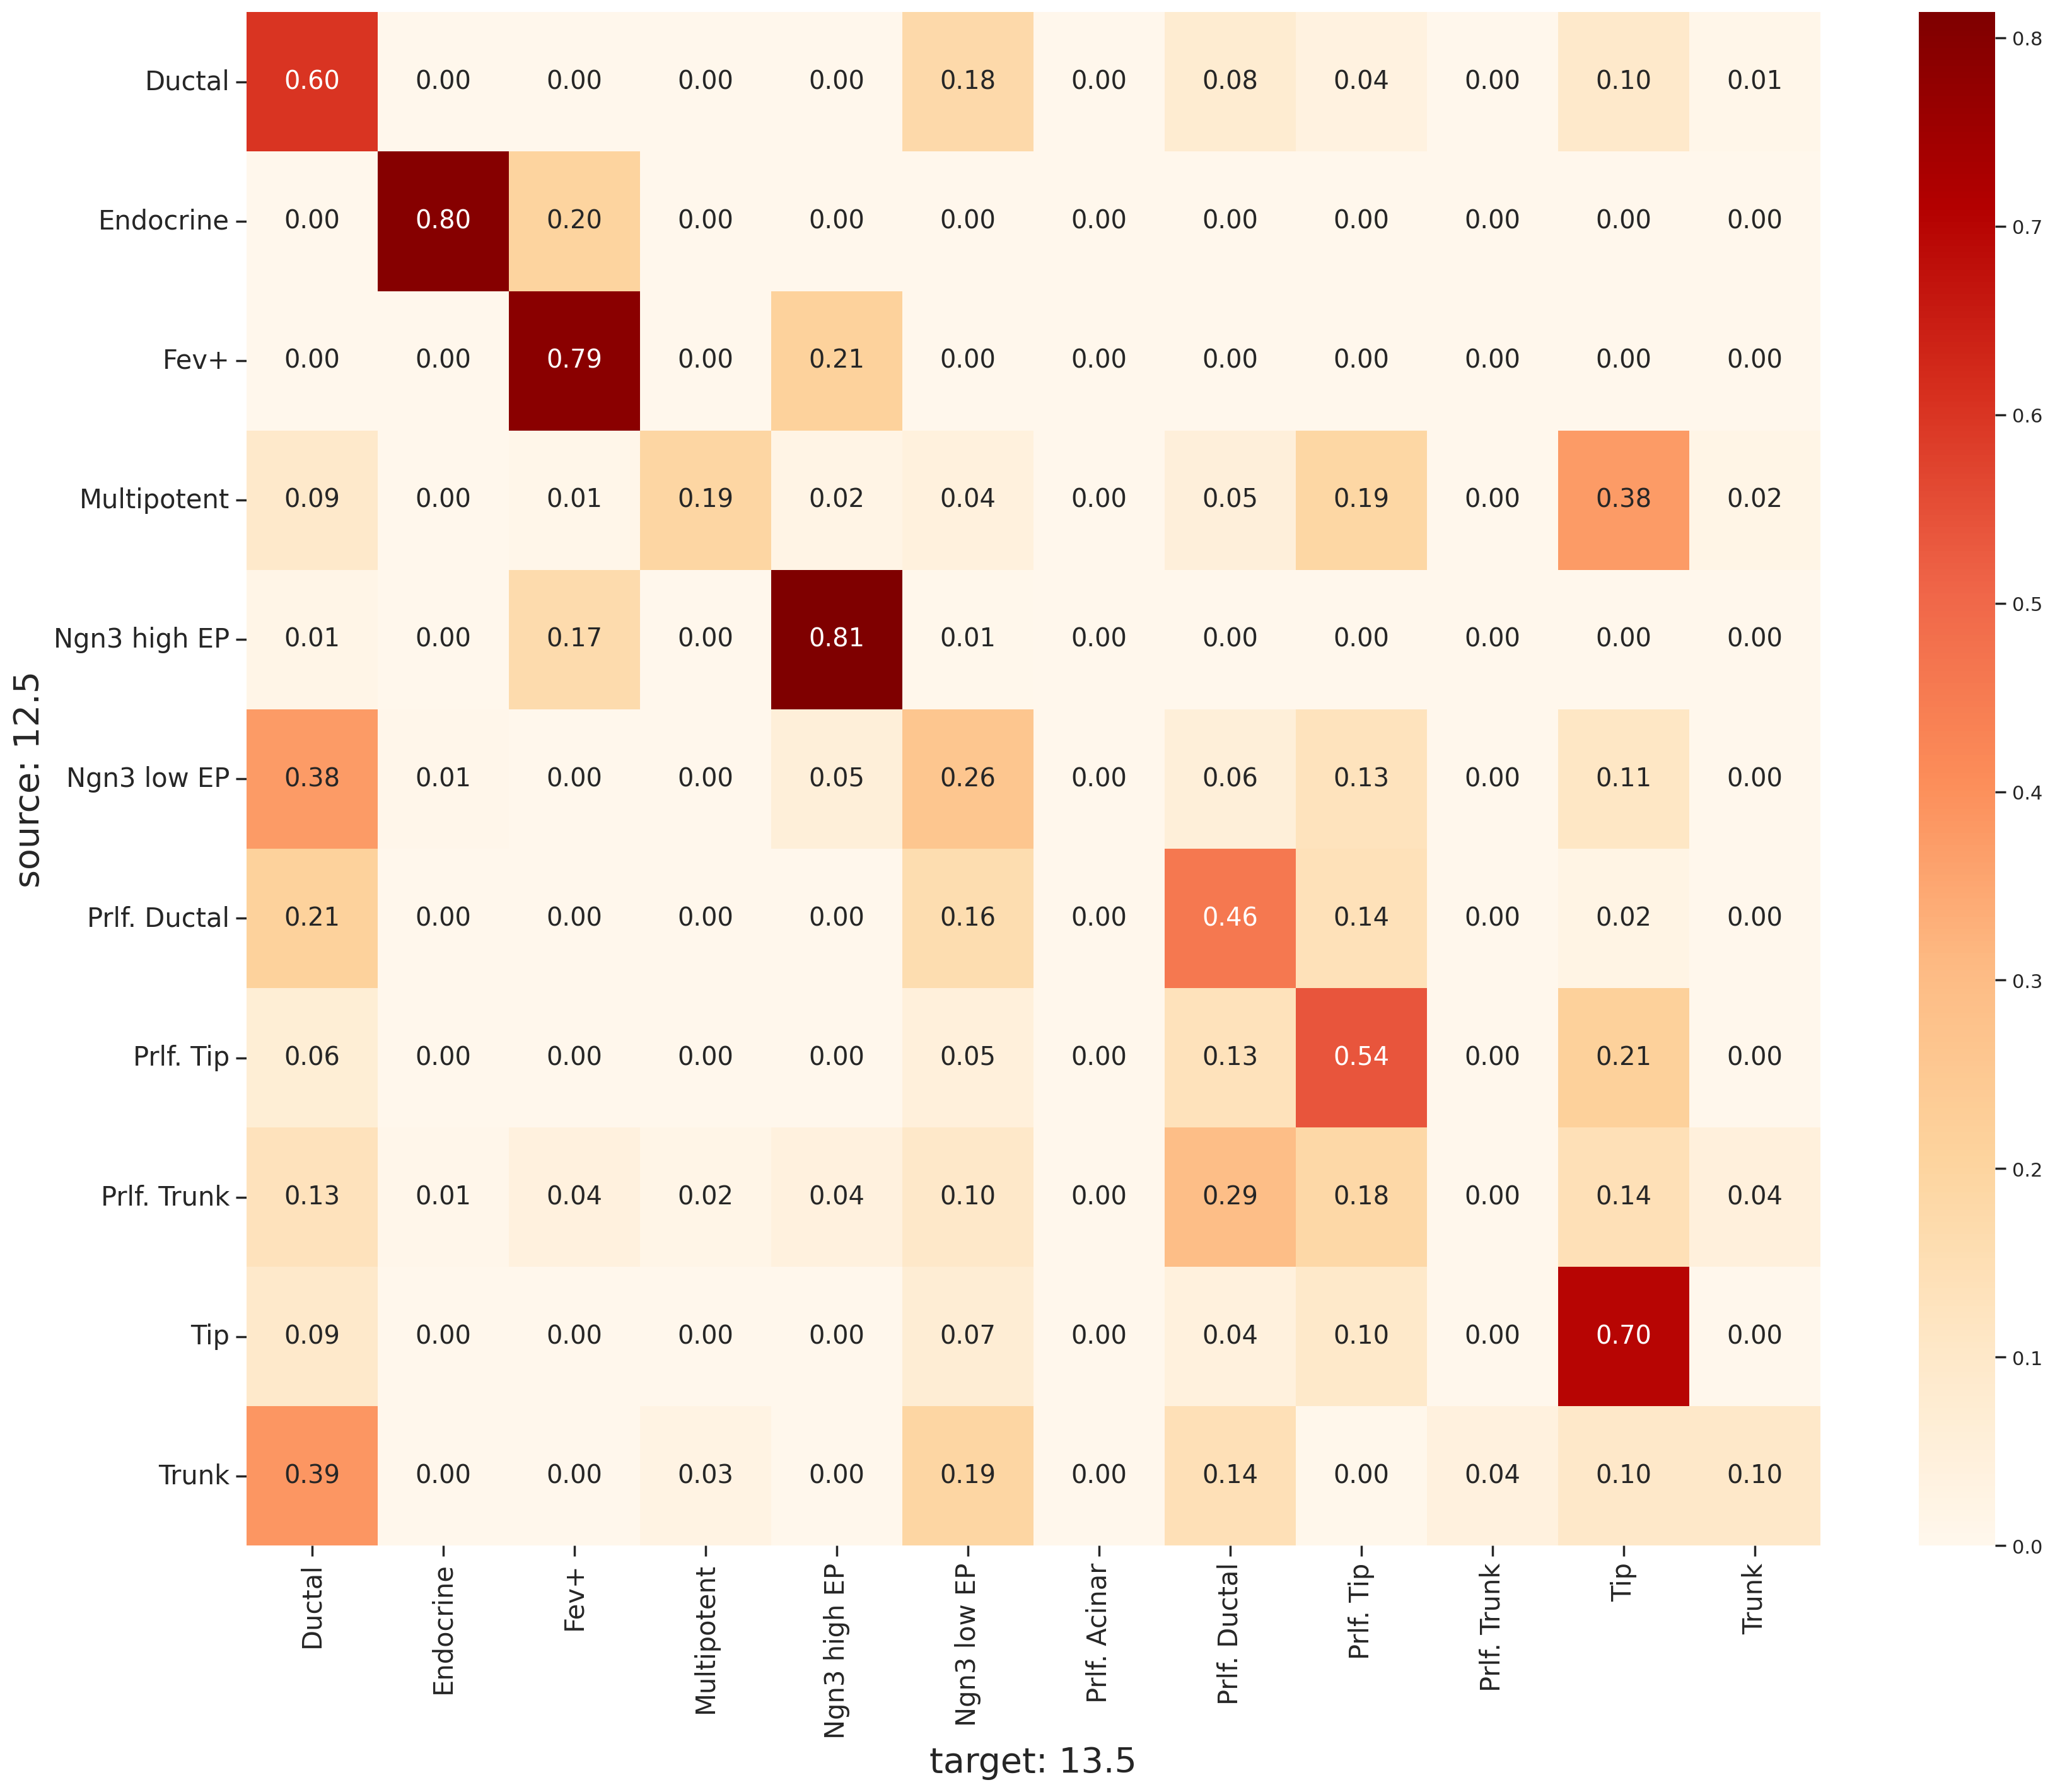

In [22]:
sc.settings.set_figure_params(dpi=100, facecolor='white', figsize=(20,16), frameon=True, fontsize=15)
sns.set_theme(style='ticks')
ax = sns.heatmap(data=tm, annot=True, fmt=".2f", annot_kws=dict(fontsize='large'), cmap='OrRd')
# ax.xaxis.tick_top()
plt.xlabel('target: {}'.format(target), fontsize=20);plt.ylabel('source: {}'.format(source), fontsize=20)
plt.xticks(rotation=90, fontsize=15);plt.yticks(rotation=0, fontsize=15)
plt.show()

### 2.3 Evaluate the performance of interpolation.

In [23]:
interpolate_times = 2
real_data = np.array(adata.X[adata.obs[time_field]==times0[interpolate_times]].todense())
print(real_data.shape)

(1000, 3000)


In [26]:
data_series = model.data_sampler.load_all()
embed_series = [model.encoder.predict(item) for item in data_series]
trans_mtx_inter = model.compute_trans_mat(times=interpolate_times-1)
print(trans_mtx_inter.shape)

(1000, 1000)


In [29]:
interp_size = real_data.shape[0]
t0, t05, t1 = times0[times-1], times0[times], times0[times+1]
print(t0, t05, t1)
interp_frac = (float(t05) - float(t0)) / (float(t1) - float(t0))
print(interp_frac)

gen_data_latent = util.interpolate(embed_series[times-1], embed_series[times], trans_mtx_inter, interp_frac, interp_size)
print(gen_data_latent.shape)
gen_data = model.decoder.predict(gen_data_latent)[-1]
print(gen_data.shape)

15.5 12.5 13.5
1.5
(1000, 30)
(1000, 3000)


In [30]:
mmd_value, pearson_corr, spearman_corr, _ = util.cal_metrics(gen_data, real_data)
print('MMD = %.3f\nPCC = %.3f\nSCC = %.3f'%(mmd_value, pearson_corr, spearman_corr))

MMD = 708.617
PCC = 0.837
SCC = 0.840
